# Introduction to LangChain

A hands-on walkthrough of core **LangChain** concepts using the **Groq API** (LLaMA 3.3 70B) for text generation and **Hugging Face's FLUX.1** for image generation.

**What this notebook covers:**
1. Setting up an LLM connection with `ChatGroq`
2. Building prompt templates (system + human messages)
3. Chaining components together with LangChain Expression Language (LCEL)
4. Generating an article title and description from raw text
5. Turning that text into an image generation prompt and rendering it with FLUX.1

### Step 1 — Configure the Groq API key and model


In [ ]:
import os

os.environ["GROQ_API_KEY"] = "put yors "


model="llama-3.3-70b-versatile"


### Step 2 — Initialize the LLMs

We create two `ChatGroq` instances from the same model, but with different `temperature` values:
- **`llm`** (`temperature=0.0`) → deterministic, focused answers. Good for tasks like titles/summaries where consistency matters.
- **`creative_llm`** (`temperature=0.9`) → more randomness/variety. Good for creative writing tasks like descriptions.


In [2]:
from langchain_groq import ChatGroq


# For normal accurate responses
llm = ChatGroq(temperature=0.0, model=model)

# For unique creative responses
creative_llm = ChatGroq(temperature=0.9, model=model)

### Step 3 — Sample input article

This is the raw text we'll feed through the pipeline. It's an excerpt from a paper on *Active Retrieval Augmented Generation*, and will be reused as input for every downstream step (title generation, description generation, and image prompt generation).


In [3]:
# real artecle from paper caled (Active Retrieval Augmented Generation)

article ="""
Despite the remarkable ability of large language models (LMs) to comprehend and generate language, they have a tendency to hallucinate and create factually inaccurate output.
 Augmenting LMs by retrieving information from external knowledge resources is one
promising solution. Most existing retrieval augmented LMs employ a retrieve-and-generate
setup that only retrieves information once based
on the input. This is limiting, however, in
more general scenarios involving generation
of long texts, where continually gathering information throughout generation is essential. In
this work, we provide a generalized view of active retrieval augmented generation, methods
that actively decide when and what to retrieve
across the course of the generation. We propose
Forward-Looking Active REtrieval augmented
generation (FLARE), a generic method which
iteratively uses a prediction of the upcoming
sentence to anticipate future content, which is
then utilized as a query to retrieve relevant documents to regenerate the sentence if it contains
low-confidence tokens. We test FLARE along
with baselines comprehensively over 4 longform knowledge-intensive generation tasks/-
datasets. FLARE achieves superior or competitive performance on all tasks, demonstrating
the effectiveness of our method
"""

### Step 4 — Build the prompt templates

LangChain prompts are typically split into two roles:
- **System prompt** — defines the AI's persona/behavior (here: an assistant named `{name}` that writes article titles).
- **Human (user) prompt** — the actual task, with the article text injected as a variable.

Using `{article}` and `{name}` as placeholders lets us reuse the same template with different inputs later.


In [4]:
from langchain_core.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate

# Defining the system prompt (how the AI should act)
system_prompt = SystemMessagePromptTemplate.from_template(
    "You are an AI assistant called {name} that helps generate article titles.",
    input_variables = ["name"]
)

# the user prompt is provided by the user, in this case however the only dynamic
# input is the article

user_prompt = HumanMessagePromptTemplate.from_template(
    """You are tasked with creating a name for a article.
The article is here for you to examine {article}

The name should be based of the context of the article.
Be creative, but make sure the names are clear, catchy,
and relevant to the theme of the article.

Only output the article name, no other explanation or
text can be provided.""",
    input_variables=["article"]
)

### Step 5 — Combine into a chat prompt

`ChatPromptTemplate.from_messages([...])` merges the system and user prompts into a single template that can be sent to the LLM as a structured conversation.


In [5]:
from langchain_core.prompts import ChatPromptTemplate

first_prompt = ChatPromptTemplate.from_messages([system_prompt, user_prompt])

### Step 6 — Build the first chain (title generation)

This uses **LCEL (LangChain Expression Language)**, where the `|` operator pipes data from one component to the next:

1. Extract `article` and `name` from the input dict
2. Format them into the prompt (`first_prompt`)
3. Send the prompt to the LLM (`llm`)
4. Wrap the response back into a `{"article_title": ...}` dict for easy downstream use


In [6]:
first_chain =(
    {"article": lambda x: x ["article"],"name": lambda x: x ["name"]}
    |first_prompt
    |llm
    |{"article_title": lambda x: x.content}
)

### Step 7 — Run the title chain

Invoke the chain with our sample `article` and a chosen assistant `name` ("scarlet") to generate a catchy, relevant title.


In [7]:
article_title_msg = first_chain.invoke({"article": article , "name":"scarlet"})
article_title_msg

{'article_title': '"Beyond Hallucinations: FLARE - A Forward-Looking Approach to Retrieval Augmented Language Generation"'}

### Step 8 — Build the second prompt (description generation)

A new human prompt asks the model to write an **SEO-friendly, non-technical description** of the article, using both the original article text and the title generated in the previous step. It's combined with the same `system_prompt` from before.


In [8]:
second_user_prompt = HumanMessagePromptTemplate.from_template(
    """You are tasked with creating a description for
the article. The article is here for you to examine:

---

{article}

---

Here is the article title '{article_title}'.

Output the SEO friendly article description and very clear to understand by non tecnical. Do not output
anything other than the description. """,
    input_variables=["article", "article_title"]
)

second_prompt = ChatPromptTemplate.from_messages([
    system_prompt,
    second_user_prompt
])

### Step 9 — Build the second chain (description generation)

Same LCEL pattern as before, but this time using `creative_llm` (higher temperature) since we want a more engaging, varied description rather than a strictly deterministic one.


In [9]:
second_chain =(
    {"article":lambda x: x["article"],"article_title":lambda x: x["article_title"],"name" :lambda x:x ["name"]}
    |second_prompt
    |creative_llm
    |{"description":lambda x : x.content }
)

### Step 10 — Run the description chain

Pass in the article, the assistant name, and the title generated earlier to produce the article's description.


In [10]:
article_discription = second_chain.invoke({"article":article, "name":"scarlet", "article_title":article_title_msg})
article_discription 

{'description': 'Imagine a future where language models can generate human-like text without making things up. Current models often "hallucinate" and produce factually inaccurate output, but what if they could retrieve information from external sources to ensure accuracy? Researchers have developed a new method called FLARE, which allows language models to actively seek out relevant information while generating text, resulting in more accurate and reliable long-form content creation. This breakthrough has the potential to revolutionize language generation, enabling machines to produce high-quality, knowledge-intensive text that is both informative and trustworthy.'}

### Step 11 — Set up image generation

Now we move to the image generation part of the pipeline, using Hugging Face's `InferenceClient` to call the **FLUX.1-schnell** text-to-image model. This requires a Hugging Face access token (`HF_TOKEN`).


In [ ]:
import os
from huggingface_hub import InferenceClient
import matplotlib.pyplot as plt
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda

# Ensure authentication and routing headers are configured cleanly
os.environ["HF_TOKEN"] = "put yours"

### Step 12 — Create the FLUX client and image prompt template

- `client` connects to the FLUX.1-schnell model on Hugging Face.
- `image_prompt_template` instructs the LLM to turn the article + title + description into a **concise (<500 character) visual prompt** suitable for image generation.


In [12]:

client = InferenceClient(
    model="black-forest-labs/FLUX.1-schnell",
    token=os.environ["HF_TOKEN"]
)

# 1. Define the Prompt Template
image_prompt_template = PromptTemplate(
    input_variables=["article","article_title","description"],
    template=(
        "Generate a highly detailed visual prompt with less than 500 characters "
        "to generate an image based on the following article content: {article}"
        "this article will have the title of {article_title}"
        "also it have the discription that will help you to write the right prompt {description}"
    )
)


### Step 13 — Define the image generation function

`generate_and_display_image()` takes a text prompt, sends it to FLUX via `client.text_to_image()`, and displays the resulting image using `matplotlib`. This will be wrapped as a **Runnable** node so it can slot into an LCEL chain.


In [13]:
# 2. Define the image generation function node
def generate_and_display_image(final_prompt_string):
    #Takes the string output from the LLM and sends it to FLUX.

    print(f"\n[FLUX Node] Generating image for prompt: '{final_prompt_string}'...")
    
    # Query the engine
    output_image = client.text_to_image(final_prompt_string)

    # Display the result on screen
    plt.imshow(output_image)
    plt.axis('off')
    plt.show()
    
    return "Generation complete."

# Wrap the node for use with LCEL
image_gen_runnable = RunnableLambda(generate_and_display_image)


### Step 14 — Assemble the full end-to-end pipeline

`chain_four` chains everything together:

1. Collect `article`, `article_title`, and `description` into a dict
2. Format them into the image prompt template
3. Send to the LLM to generate a concise visual description
4. Extract the text content from the LLM response
5. Pass that final prompt into `image_gen_runnable` to generate and display the image

This demonstrates how LangChain can orchestrate multi-step pipelines that mix **text generation and other tools** (like image generation) in one chain.


In [14]:
# 3. Assemble the complete pipeline
chain_four = (
    {"article": lambda x: x["article"] , "article_title": lambda x: x["article_title"], "description": lambda x: x["description"]}
    | image_prompt_template 
    | llm
    | (lambda x: x.content)
    | image_gen_runnable
)


### Step 15 — Run the full pipeline

Invoke `chain_four` with the article, title, and description generated in earlier steps to produce and display the final AI-generated image.


Starting pipeline chain...

[FLUX Node] Generating image for prompt: '"A futuristic library with a language model at its core, surrounded by glowing orbs representing external knowledge sources, as it generates text on a holographic screen with FLARE method."'...


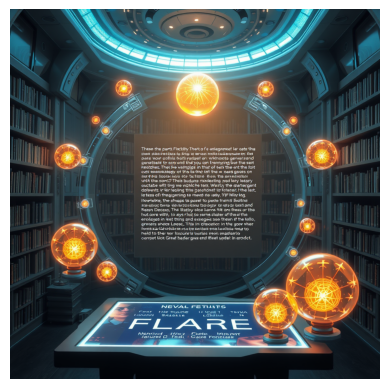

'Generation complete.'

In [15]:

print("Starting pipeline chain...")
chain_four.invoke({"article": article,"article_title":article_title_msg ,"description":article_discription})